# Mortality Risk Prediction and Age Acceleration Analysis

This notebook demonstrates how to:
1. Load a fine-tuned mortality prediction model
2. Predict mortality risk from metabolomic data
3. Convert risk scores to age acceleration (delta age) using debiased age gap calculation
4. Visualize the results

## Dataset
Data source: UKB NMR validation set

## 1. Import Required Libraries

In [1]:
import os
import sys
import torch
import numpy as np
import pandas as pd
import anndata as ad
from tqdm import tqdm
import matplotlib.pyplot as plt
import seaborn as sns
import joblib
import json

# Add Src directory to path
sys.path.append('./Src')

from metfoundation_torch.models import MetFoundation_Survival
from metfoundation_torch.dataset import load_dataset_from_adata_NMR
from utils import load_tokenizer, set_seeds

print("Libraries imported successfully!")
print(f"PyTorch version: {torch.__version__}")
print(f"CUDA available: {torch.cuda.is_available()}")

Libraries imported successfully!
PyTorch version: 2.3.0
CUDA available: False


## 2. Configuration

Set up paths and parameters for model loading and prediction.

In [2]:
# Set random seed for reproducibility
set_seeds(3047)

# Configuration paths
pretrained_model_dir = './Model_Weights/MetFoundation'
survival_model_path = './Model_Weights/SurvivalModule/model_weights.pth'
risk2age_model_path = './Defined_Tools/Risk2AgeAccel_model.joblib'
data_path = './Data/UKB_NMR/val.h5ad'

# Processing parameters
batch_size = 128
device = "cuda" if torch.cuda.is_available() else "cpu"

print(f"Pre-trained model directory: {pretrained_model_dir}")
print(f"Survival model path: {survival_model_path}")
print(f"Risk2Age model path: {risk2age_model_path}")
print(f"Data path: {data_path}")
print(f"Device: {device}")

Pre-trained model directory: ./Model_Weights/MetFoundation
Survival model path: ./Model_Weights/SurvivalModule/model_weights.pth
Risk2Age model path: ./Defined_Tools/Risk2AgeAccel_model.joblib
Data path: ./Data/UKB_NMR/val.h5ad
Device: cpu


## 3. Load Data

Load the metabolomic data from the h5ad file and inspect its structure.

In [3]:
# Load the validation dataset
dataloader, adata = load_dataset_from_adata_NMR(
    data_path,
    shuffle=False,
    batch_size=batch_size,
    device=device
)

print(f"Data loaded successfully!")
print(f"Number of samples: {adata.n_obs}")
print(f"Number of metabolites: {adata.n_vars}")
print(f"Number of batches: {len(dataloader)}")
print(f"\nAvailable columns in observations:")
for col in adata.obs.columns:
    print(f"  - {col}")

Data loaded successfully!
Number of samples: 4320
Number of metabolites: 107
Number of batches: 34

Available columns in observations:
  - Age at assessment (estimated)
  - Sex
  - Body mass index (BMI)
  - UK Biobank assessment centre
  - Date of attending assessment centre
  - Death follow-up time
  - Death event
  - Death event time
  - UK Biobank assessment area
  - instance


## 4. Load Pre-trained Model and Tokenizer

Load the tokenizer and model configuration from the pre-trained MetFoundation model.

In [4]:
# Load tokenizer
tokenizer_path = os.path.join(pretrained_model_dir, 'tokenizer.pkl')
if not os.path.exists(tokenizer_path):
    raise FileNotFoundError(f"Tokenizer not found at: {tokenizer_path}")

Tokenizer = load_tokenizer(tokenizer_path)
print(f"Tokenizer loaded successfully!")
print(f"Vocabulary size: {Tokenizer.vocab_size_identifiers}")

# Load model configuration
config_path = os.path.join(pretrained_model_dir, 'config.json')
if not os.path.exists(config_path):
    raise FileNotFoundError(f"Configuration file not found at: {config_path}")

with open(config_path, 'r') as f:
    model_config = json.load(f)

print(f"\nModel Configuration:")
print(f"  - Number of heads: {model_config['n_heads']}")
print(f"  - Number of blocks: {model_config['n_blocks']}")
print(f"  - Model dimension: {model_config['d_model']}")
print(f"  - Feed-forward dimension: {model_config['d_ff']}")

Tokenizer loaded successfully!
Vocabulary size: 107

Model Configuration:
  - Number of heads: 8
  - Number of blocks: 6
  - Model dimension: 512
  - Feed-forward dimension: 2048


## 5. Load Fine-tuned Survival Model

Load the MetFoundation model with fine-tuned survival prediction head.

In [5]:
# Prepare embedding module configuration
EmbeddingModule_conf = {
    "n_vocabs": {'identifier': Tokenizer.vocab_size_identifiers}
}

# Load pre-trained model weights
model_weights_path = os.path.join(pretrained_model_dir, 'model_weights.pth')
if not os.path.exists(model_weights_path):
    raise FileNotFoundError(f"Model weights not found at: {model_weights_path}")

# Initialize survival model
model = MetFoundation_Survival(
    EmbeddingModule_conf, 
    model_config, 
    model_weights_path
)

# Load fine-tuned risk head weights
if not os.path.exists(survival_model_path):
    raise FileNotFoundError(f"Survival model weights not found at: {survival_model_path}")

model._load_risk_head_weights(survival_model_path)
model.to(device)
model.eval()

print("Survival model loaded successfully!")
print(f"Model is on device: {next(model.parameters()).device}")

Survival model loaded successfully!
Model is on device: cpu


## 6. Predict Mortality Risk

Run inference on the validation dataset to obtain mortality risk scores.

In [6]:
# Collect predictions
risk_scores = []
ages = []
sample_ids = []

print("Predicting mortality risk...")
with torch.no_grad():
    for batch_data in tqdm(dataloader, desc="Processing batches"):
        # Tokenize inputs
        inputs, _ = Tokenizer.tokenize_from_anndata(
            batch_data, 
            padding='longest', 
            masking='missing', 
            data_layer='Z-score normalized', 
            mode='inference',
            return_tensor=True, 
            device=device
        )
        
        # Get chronological age
        age = batch_data.obs['Age at assessment (estimated)'].values
        age_normalized = torch.Tensor(age / 100).to(device)
        
        # Model forward pass
        outputs = model(inputs, age_normalized)
        risk = outputs['logit_risk']
        
        # Collect results
        risk_scores.append(risk.cpu().numpy())
        ages.append(age)
        sample_ids.extend(batch_data.obs_names.tolist())

# Concatenate results
risk_scores = np.concatenate(risk_scores).flatten()
ages = np.concatenate(ages).flatten()

print(f"\nPrediction completed!")
print(f"Number of samples: {len(risk_scores)}")
print(f"Risk score range: [{risk_scores.min():.4f}, {risk_scores.max():.4f}]")
print(f"Age range: [{ages.min():.1f}, {ages.max():.1f}]")

Predicting mortality risk...


Processing batches:   0%|          | 0/34 [00:00<?, ?it/s]/home/comp/csyuxu/anaconda3/envs/MetFoundation/lib/python3.12/site-packages/sympy/external/gmpy.py:139: UserWarning: gmpy2 version is too old to use (2.0.0 or newer required)
  gmpy = import_module('gmpy2', min_module_version=_GMPY2_MIN_VERSION,
/home/comp/csyuxu/anaconda3/envs/MetFoundation/lib/python3.12/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm
Processing batches: 100%|██████████| 34/34 [00:48<00:00,  1.44s/it]


Prediction completed!
Number of samples: 4320
Risk score range: [1.4831, 7.0300]
Age range: [40.2, 70.3]


## 7. Load Risk-to-Age Acceleration Model

Load the pre-trained DebiasedAgeGapCalculator to convert risk scores to age acceleration.

In [7]:
class DebiasedAgeGapCalculator:
    def __init__(self):
        self.risk_coef_ = None
        self.age_coef_ = None
        self.intercept_ = None
        self.is_fitted_ = False
        
    def fit(self, risk, age):
        # risk -> age
        risk2age_model = LinearRegression()
        risk2age_model.fit(risk.reshape(-1, 1), age)
        met_age = risk2age_model.predict(risk.reshape(-1, 1))
        
        # age -> met_age 
        bias_model = LinearRegression()
        bias_model.fit(age.reshape(-1, 1), met_age)
        
        # MetAgeGap = risk*β1 - age*β2 + intercept
        self.risk_coef_ = risk2age_model.coef_[0]
        self.age_coef_ = bias_model.coef_[0]  
        self.intercept_ = risk2age_model.intercept_ - bias_model.intercept_
        
        self.is_fitted_ = True
        return self
    
    def predict(self, risk, age):
        if not self.is_fitted_:
            raise ValueError("Model must be fitted first")
        
        return (self.risk_coef_ * risk - 
                self.age_coef_ * age + 
                self.intercept_)
    
    def fit_predict(self, risk, age):
        return self.fit(risk, age).predict(risk, age)
    

In [8]:
# Load the Risk2AgeAccel model
if not os.path.exists(risk2age_model_path):
    raise FileNotFoundError(f"Risk2Age model not found at: {risk2age_model_path}")

risk2age_model = joblib.load(risk2age_model_path)

print("Risk2AgeAccel model loaded successfully!")
print(f"\nModel coefficients:")
print(f"  - Risk coefficient: {risk2age_model.risk_coef_:.6f}")
print(f"  - Age coefficient: {risk2age_model.age_coef_:.6f}")
print(f"  - Intercept: {risk2age_model.intercept_:.6f}")

Risk2AgeAccel model loaded successfully!

Model coefficients:
  - Risk coefficient: 7.214727
  - Age coefficient: 0.684350
  - Intercept: 11.552841


## 8. Calculate Age Acceleration (Delta Age)

Convert risk scores to age acceleration using the debiased age gap calculator.
Age acceleration represents the deviation from expected biological aging.

In [9]:
# Calculate age acceleration
age_acceleration = risk2age_model.predict(risk_scores, ages)

print(f"Age acceleration calculated!")
print(f"Age acceleration range: [{age_acceleration.min():.2f}, {age_acceleration.max():.2f}] years")
print(f"Mean age acceleration: {age_acceleration.mean():.2f} years")
print(f"Std age acceleration: {age_acceleration.std():.2f} years")

# Create results dataframe
results_df = pd.DataFrame({
    'sample_id': sample_ids,
    'chronological_age': ages,
    'risk_score': risk_scores,
    'age_acceleration': age_acceleration,
    'biological_age': ages + age_acceleration
})



Age acceleration calculated!
Age acceleration range: [-9.57, 19.78] years
Mean age acceleration: -0.04 years
Std age acceleration: 3.67 years


## 9. Visualization

Visualize the relationships between age, risk, and age acceleration.

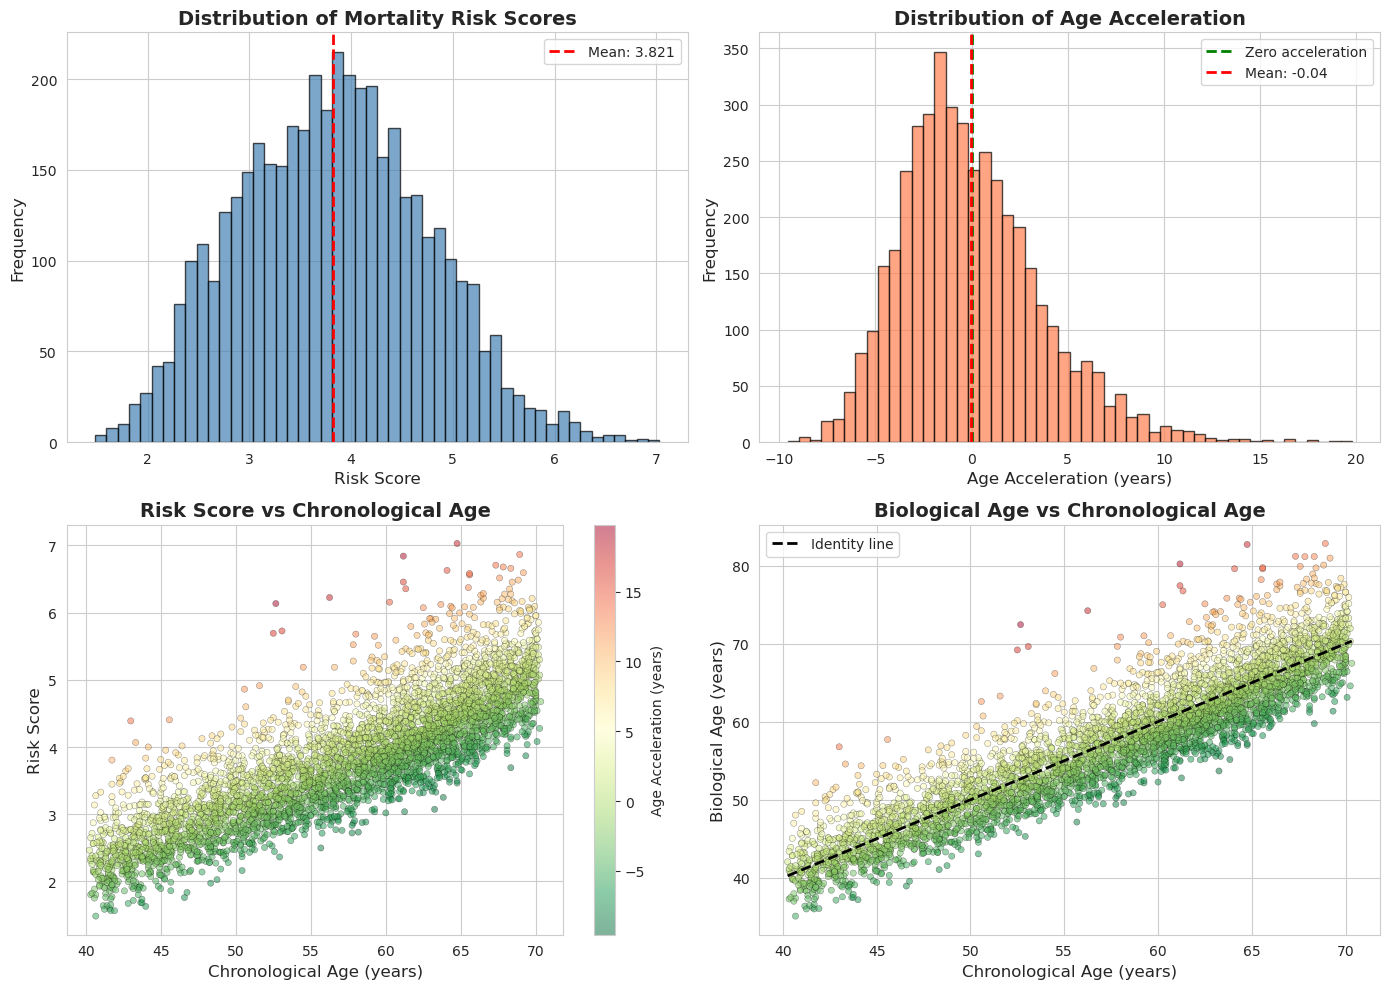

Visualization completed and saved!


In [10]:
# Set up the plotting style
sns.set_style("whitegrid")
fig, axes = plt.subplots(2, 2, figsize=(14, 10))

# Plot 1: Risk Score Distribution
axes[0, 0].hist(risk_scores, bins=50, color='steelblue', edgecolor='black', alpha=0.7)
axes[0, 0].set_xlabel('Risk Score', fontsize=12)
axes[0, 0].set_ylabel('Frequency', fontsize=12)
axes[0, 0].set_title('Distribution of Mortality Risk Scores', fontsize=14, fontweight='bold')
axes[0, 0].axvline(risk_scores.mean(), color='red', linestyle='--', linewidth=2, label=f'Mean: {risk_scores.mean():.3f}')
axes[0, 0].legend()

# Plot 2: Age Acceleration Distribution
axes[0, 1].hist(age_acceleration, bins=50, color='coral', edgecolor='black', alpha=0.7)
axes[0, 1].set_xlabel('Age Acceleration (years)', fontsize=12)
axes[0, 1].set_ylabel('Frequency', fontsize=12)
axes[0, 1].set_title('Distribution of Age Acceleration', fontsize=14, fontweight='bold')
axes[0, 1].axvline(0, color='green', linestyle='--', linewidth=2, label='Zero acceleration')
axes[0, 1].axvline(age_acceleration.mean(), color='red', linestyle='--', linewidth=2, label=f'Mean: {age_acceleration.mean():.2f}')
axes[0, 1].legend()

# Plot 3: Risk vs Chronological Age
scatter = axes[1, 0].scatter(ages, risk_scores, c=age_acceleration, cmap='RdYlGn_r', 
                            alpha=0.5, s=20, edgecolors='black', linewidth=0.3)
axes[1, 0].set_xlabel('Chronological Age (years)', fontsize=12)
axes[1, 0].set_ylabel('Risk Score', fontsize=12)
axes[1, 0].set_title('Risk Score vs Chronological Age', fontsize=14, fontweight='bold')
cbar = plt.colorbar(scatter, ax=axes[1, 0])
cbar.set_label('Age Acceleration (years)', fontsize=10)

# Plot 4: Biological Age vs Chronological Age
axes[1, 1].scatter(ages, ages + age_acceleration, alpha=0.5, s=20, 
                   c=age_acceleration, cmap='RdYlGn_r', edgecolors='black', linewidth=0.3)
axes[1, 1].plot([ages.min(), ages.max()], [ages.min(), ages.max()], 
                'k--', linewidth=2, label='Identity line')
axes[1, 1].set_xlabel('Chronological Age (years)', fontsize=12)
axes[1, 1].set_ylabel('Biological Age (years)', fontsize=12)
axes[1, 1].set_title('Biological Age vs Chronological Age', fontsize=14, fontweight='bold')
axes[1, 1].legend()

plt.tight_layout()
# plt.savefig('mortality_risk_age_acceleration_analysis.png', dpi=300, bbox_inches='tight')
plt.show()

print("Visualization completed and saved!")

## 10. Statistical Summary

Provide statistical summary of the results.

In [11]:
# Calculate percentiles
percentiles = [10, 25, 50, 75, 90]
risk_percentiles = np.percentile(risk_scores, percentiles)
age_accel_percentiles = np.percentile(age_acceleration, percentiles)

print("="*60)
print("STATISTICAL SUMMARY")
print("="*60)

print("\nRisk Score Statistics:")
print(f"  Mean: {risk_scores.mean():.4f}")
print(f"  Std: {risk_scores.std():.4f}")
print(f"  Min: {risk_scores.min():.4f}")
print(f"  Max: {risk_scores.max():.4f}")
print(f"  Percentiles:")
for p, val in zip(percentiles, risk_percentiles):
    print(f"    {p}th: {val:.4f}")

print("\nAge Acceleration Statistics:")
print(f"  Mean: {age_acceleration.mean():.2f} years")
print(f"  Std: {age_acceleration.std():.2f} years")
print(f"  Min: {age_acceleration.min():.2f} years")
print(f"  Max: {age_acceleration.max():.2f} years")
print(f"  Percentiles:")
for p, val in zip(percentiles, age_accel_percentiles):
    print(f"    {p}th: {val:.2f} years")

# Categorize samples based on age acceleration
accelerated = np.sum(age_acceleration > 5)
normal = np.sum((age_acceleration >= -5) & (age_acceleration <= 5))
decelerated = np.sum(age_acceleration < -5)

print("\nAge Acceleration Categories:")
print(f"  Accelerated aging (>5 years): {accelerated} ({100*accelerated/len(age_acceleration):.1f}%)")
print(f"  Normal aging (-5 to 5 years): {normal} ({100*normal/len(age_acceleration):.1f}%)")
print(f"  Decelerated aging (<-5 years): {decelerated} ({100*decelerated/len(age_acceleration):.1f}%)")

print("\nCorrelation Analysis:")
corr_risk_age = np.corrcoef(risk_scores, ages)[0, 1]
corr_accel_age = np.corrcoef(age_acceleration, ages)[0, 1]
corr_risk_accel = np.corrcoef(risk_scores, age_acceleration)[0, 1]

print(f"  Risk score vs Chronological age: {corr_risk_age:.4f}")
print(f"  Age acceleration vs Chronological age: {corr_accel_age:.4f}")
print(f"  Risk score vs Age acceleration: {corr_risk_accel:.4f}")
print("="*60)

STATISTICAL SUMMARY

Risk Score Statistics:
  Mean: 3.8209
  Std: 0.9249
  Min: 1.4831
  Max: 7.0300
  Percentiles:
    10th: 2.5871
    25th: 3.1336
    50th: 3.8210
    75th: 4.4529
    90th: 5.0403

Age Acceleration Statistics:
  Mean: -0.04 years
  Std: 3.67 years
  Min: -9.57 years
  Max: 19.78 years
  Percentiles:
    10th: -4.26 years
    25th: -2.61 years
    50th: -0.54 years
    75th: 2.06 years
    90th: 4.76 years

Age Acceleration Categories:
  Accelerated aging (>5 years): 402 (9.3%)
  Normal aging (-5 to 5 years): 3675 (85.1%)
  Decelerated aging (<-5 years): 243 (5.6%)

Correlation Analysis:
  Risk score vs Chronological age: 0.8355
  Age acceleration vs Chronological age: 0.0027
  Risk score vs Age acceleration: 0.5518


## 11. Save Results

Save the results to a CSV file for further analysis.

In [ ]:
# Save results
output_file = os.path.join('./Demo_output', 'mortality_risk_age_acceleration_results.csv')
results_df.to_csv(output_file, index=False)
print(f"Results saved to: {output_file}")



Results saved to: mortality_risk_age_acceleration_results.csv


## Summary

This notebook demonstrated:
1. **Data Loading**: Loaded metabolomic data from UKB NMR validation set
2. **Model Loading**: Loaded pre-trained MetFoundation model with fine-tuned survival prediction head
3. **Risk Prediction**: Generated mortality risk scores for all samples
4. **Age Acceleration**: Converted risk scores to debiased age acceleration using the Risk2AgeAccel model
5. **Visualization**: Created comprehensive visualizations showing relationships between age, risk, and biological aging
6. **Statistical Analysis**: Provided detailed statistical summaries and categorization of aging patterns

### Key Insights:
- Age acceleration represents the deviation of biological age from chronological age
- Positive values indicate accelerated aging (higher mortality risk)
- Negative values indicate decelerated aging (lower mortality risk)
- The debiased calculation removes systematic age-related biases
